In [1]:
%load_ext autoreload
import sys
from pathlib import Path
import networkx as nx
import numpy as np
import seaborn as sns
from scipy.linalg import eigh
import matplotlib.pyplot as plt
import scipy.linalg as sla
import pandas as pd
import copy

In [2]:
project_root = Path().resolve()
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2    
from lib.graph_factory import GraphFactory, add_graph_plot, calc_graph_metrics
from lib.utils import rng, seed
from lib.config import BASE_CONF, GLOBAL_SEED, NUM_NODES
from lib.metrics import effective_mixing, MetricsCalculator
from lib.utils import fetch_dataset, dirichlet_partition

In [4]:
def calc_constants(W, H, B, gamma_vec, pi_t):
    Wb, pi, lam = effective_mixing(W, H, gamma_vec, pi_t)
    dp = dirichlet_partition(global_dataset['y_train'], NUM_NODES, config['data_heterogeneity'], rng('dir', 'data', 'graphs'))
    dB_max = max(W[i, B].sum() for i in H) if len(B) else 0.0
    return dict(dB_max=dB_max)

In [5]:
config = copy.deepcopy(BASE_CONF)
b = 9
config['graph_weights'] = 'MH_gen'
config['graph_args'] = {
    'ba_m': 5,
    'ws_k': 6,
    'ws_p': 0.1,
    'rand_reg_deg':10,
    'geom_radius':0.6,
    'er_p':min(1.0, 3.0 * np.log(NUM_NODES) / NUM_NODES),
}
# pi = np.full(NUM_NODES, 1.0/NUM_NODES) 
pi = rng('dir','graphs').dirichlet(np.full(NUM_NODES,2))
gamma = np.clip((0.03*np.linspace(-1,1,NUM_NODES)) + 0.2, 0, 0.95)
pi_t = (1 - gamma) * pi
config['graph_args']['MH_target_pi'] = pi_t

# Notebook Variables
graphs = ['random-regular', 'geometric', 'watts-strogatz', 'erdos-renyi', 'barabasi-albert']
local_seed = 333

In [6]:
global_dataset = fetch_dataset('MNIST')
mc = MetricsCalculator(config, global_dataset, rng('mc','exp11'))
gf = GraphFactory(NUM_NODES, b)

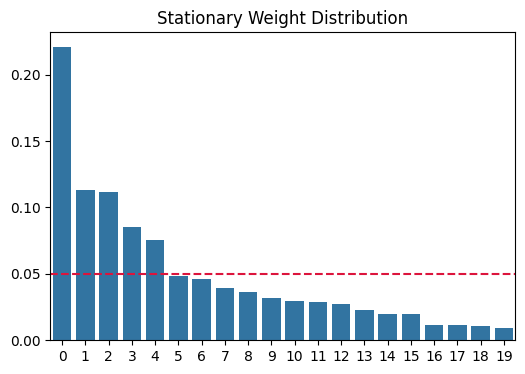

In [7]:
fig, ax = plt.subplots(1,1, figsize=(6,4))
sns.barplot(x=np.arange(NUM_NODES), y=np.sort(pi)[::-1], ax=ax)
ax.axhline(1/NUM_NODES, ls="--", color="crimson")
ax.set_title("Stationary Weight Distribution")
plt.show()

In [10]:
G,W,B,H = gf.create_graph(graphs[0], config['graph_weights'], local_seed+(37*1) , **config['graph_args'])

In [11]:
H

array([ 1,  2,  7,  9, 10, 12, 13, 14, 16, 17, 19])

In [21]:
Y = W - (np.eye(NUM_NODES) * np.diag(W))

In [24]:
x = 1 - Y.sum(axis=1)

In [25]:
x

array([1.98946464e-01, 7.51824139e-02, 1.39262967e-01, 1.32797858e-01,
       1.78415249e-01, 4.67890905e-01, 5.37955362e-01, 0.00000000e+00,
       3.15124613e-01, 1.05586927e-02, 7.48127846e-01, 4.96506332e-01,
       3.09420899e-01, 1.15126381e-02, 5.31830843e-01, 3.33703169e-01,
       1.11022302e-16, 3.11028456e-01, 2.17620272e-02, 4.49750257e-01])

In [27]:
config['train']['fpr_mean'] = 0.2
config['train']['fpr_spread'] = 0.05
y = np.clip((config['train']['fpr_spread']*np.linspace(-1,1,NUM_NODES)) + \
                                     config['train']['fpr_mean'], 0, 0.95)

In [30]:
y[H].shape

(11,)

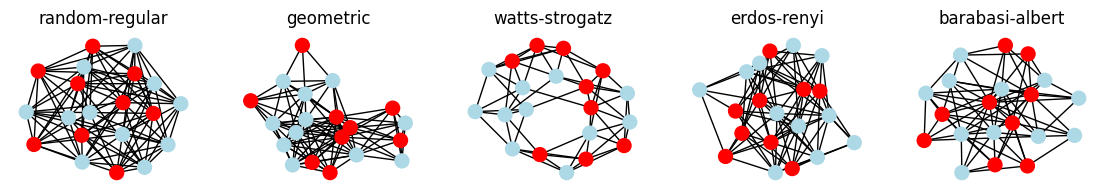

,dB_max,spectral_gap,g,lam_pi,nu2
graph,,,,,
barabasi-albert,0.5547,0.0726,0.0443,0.9629,0.0277
erdos-renyi,0.5618,0.1463,0.1086,0.9304,0.0242
geometric,0.5220,0.1384,0.1098,0.9331,0.0178
random-regular,0.5500,0.1750,0.1503,0.9117,0.0173
watts-strogatz,0.6304,0.0814,0.0131,0.9755,0.0349


In [8]:
fig, ax = plt.subplots(1,5, figsize=(14,2))
rows = []
running = True
for i in range(500):
    if running:
        for g_idx, g in enumerate(graphs):
            try:
                metrics = {'graph':g}
                G,W,B,H = gf.create_graph(g, config['graph_weights'], local_seed+(37*i) , **config['graph_args'])
                metrics.update(calc_constants(W, H, B, gamma, pi_t))
                metrics.update(calc_graph_metrics(W,H,gamma,pi_t))
                rows.append(metrics)
                if i == 0:
                    add_graph_plot(G,B,ax[g_idx])
                    ax[g_idx].set_title(g)
            except Exception as e:
                print(f"Une erreur est survenue: {e}")
                print(f"in iter {i}: failed to calculate metrics on {g} graph")
                running = False
                break
if(running):
    df = pd.DataFrame(rows).groupby('graph').agg('mean').round(4)
    fig.savefig("topologies.png", dpi=300, bbox_inches='tight')
    df.to_csv('topology_metrics.csv')
    plt.show()
    display(df)
else:
    plt.close()